In [2]:
import pandas as pd

df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [3]:
print(df.shape)
print(df.info())
print(df.isnull().sum())

(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

In [4]:
print(df['Churn'].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [5]:
df.drop('customerID', axis=1, inplace=True)

In [6]:
df['Churn'] = df['Churn'].map({
    'Yes':1,
    'No':0
})

In [7]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

df.fillna(df.median(numeric_only=True), inplace=True)

In [8]:
df = pd.get_dummies(
    df,
    drop_first=True
)

In [9]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)

y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [11]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [12]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [13]:
pred = rf.predict(X_test)

In [14]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print(
    accuracy_score(
        y_test,
        pred
    )
)

print(
    classification_report(
        y_test,
        pred
    )
)

0.7899219304471257
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1036
           1       0.65      0.46      0.54       373

    accuracy                           0.79      1409
   macro avg       0.73      0.68      0.70      1409
weighted avg       0.78      0.79      0.78      1409



In [15]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators':[100,200],
    'max_depth':[5,10,15]
}

grid = GridSearchCV(
    RandomForestClassifier(),
    params,
    cv=5
)

grid.fit(X_train,y_train)

print(grid.best_params_)

{'max_depth': 10, 'n_estimators': 200}


In [17]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred)

print(cm)

[[942  94]
 [202 171]]


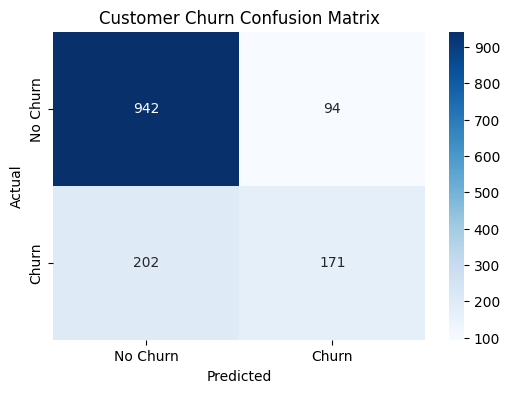

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Churn','Churn'],
    yticklabels=['No Churn','Churn']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Customer Churn Confusion Matrix')

plt.show()

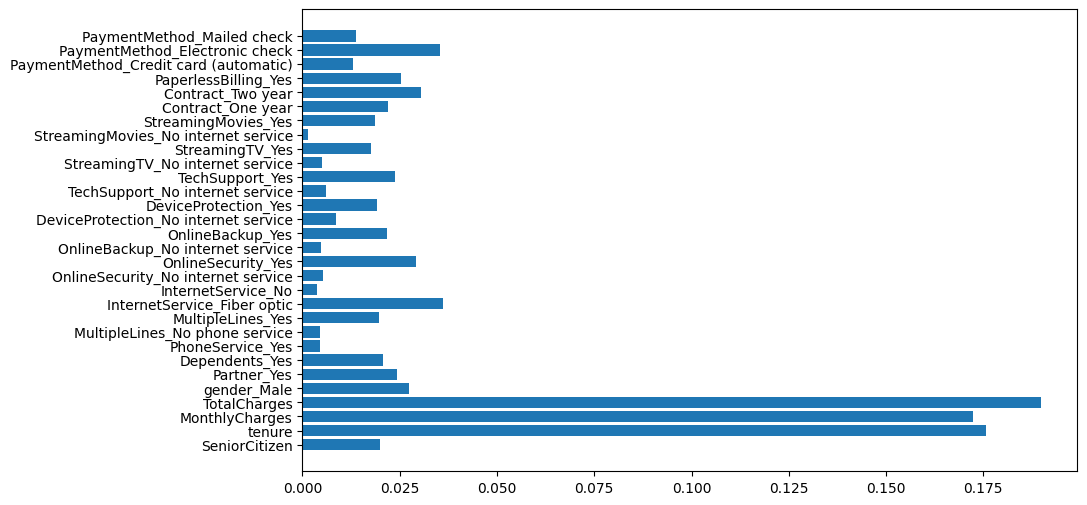

In [16]:
import matplotlib.pyplot as plt

importance = rf.feature_importances_

features = X.columns

plt.figure(figsize=(10,6))

plt.barh(
    features,
    importance
)

plt.show()

In [19]:
import joblib

joblib.dump(
    rf,
    'customer_churn_model.pkl'
)

['customer_churn_model.pkl']